<a href="https://colab.research.google.com/github/amandachipolito/Trabalho-BCI/blob/organizacao-codigo/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto BCI — Covert Shifts of Attention

## Organização estrutural do notebook

Este notebook organiza o pipeline atual do grupo para análise do dataset **Covert Shifts of Attention (BNCI 005-2015)**.

A pergunta operacional do projeto é:

> É possível estimar a direção da atenção visual encoberta a partir de modulações da banda alfa no EEG?

O notebook está organizado em duas abordagens principais:

1. **Baseline espectral:** Welch + Log10 da potência alfa + SVM.
2. **Modelo espacial:** CSP + SVM.

A comparação entre essas duas abordagens sustenta a interpretação central do trabalho: a informação espacial do EEG melhora a separação entre direções de atenção visual.


# 1. Preparação do ambiente


## 1.1 Instalação das bibliotecas


In [1]:
import sys
!{sys.executable} -m ensurepip --default-pip

%pip install --upgrade pip
%pip install numpy scipy gdown matplotlib scikit-learn mne


/usr/bin/python3: No module named ensurepip


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1.2 Importação das bibliotecas


In [2]:
import glob
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt, welch

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

import mne
from mne.preprocessing import ICA
from mne.decoding import CSP


# 2. Carregamento dos dados

Nesta etapa definimos a pasta de trabalho, baixamos os arquivos `.mat` do Google Drive e verificamos se os dados foram encontrados corretamente.


## 2.1 Definir pasta local e link do Google Drive


In [3]:
IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("/content/Projeto_BCI" if IN_COLAB else "./Projeto_BCI").resolve()

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1l2wfRKe3_xGU0otL7aIvcwXn578fGs7a?usp=sharing"

print("Pasta dos dados:", DATA_DIR)

Pasta dos dados: /workspaces/Trabalho-BCI/Projeto_BCI


## 2.2 Baixar arquivos `.mat`


In [4]:
if not DATA_DIR.exists():
    import gdown

    print(f"Baixando arquivos para: {DATA_DIR}")
    gdown.download_folder(
        GDRIVE_FOLDER_URL,
        output=str(DATA_DIR),
        quiet=False,
        use_cookies=False
    )
else:
    print("A pasta já existe. Download não realizado novamente.")

A pasta já existe. Download não realizado novamente.


## 2.3 Listar arquivos encontrados


In [5]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"{len(files)} arquivos .mat encontrados:")

for file in files:
    print(os.path.basename(file))

3 arquivos .mat encontrados:
covertShiftsOfAttention_VPgao.mat
covertShiftsOfAttention_VPiaa.mat
covertShiftsOfAttention_VPiac.mat


## 2.4 Carregar sinais EEG e frequência de amostragem


In [6]:
data_list = []
fs_list = []
nomes_arquivos = []

for fname in files:
    nome = os.path.basename(fname)

    mat = loadmat(fname, squeeze_me=True, struct_as_record=False)

    data = mat["data"]

    X = np.asarray(data.X, dtype=float)
    fs = int(data.fs)

    data_list.append(X)
    fs_list.append(fs)
    nomes_arquivos.append(nome)

    print(f"{nome}")
    print(f"  X shape: {X.shape}")
    print(f"  fs: {fs} Hz")
    print()

covertShiftsOfAttention_VPgao.mat
  X shape: (579736, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiaa.mat
  X shape: (581804, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiac.mat
  X shape: (657660, 62)
  fs: 200 Hz



## 2.5 Conferir frequência de amostragem


In [7]:
frequencias = sorted(set(fs_list))

print("Frequências encontradas:", frequencias)

if len(frequencias) == 1:
    fs = frequencias[0]
    print(f"Todos os arquivos têm fs = {fs} Hz")
else:
    print("Atenção: existem frequências diferentes entre os arquivos.")

Frequências encontradas: [200]
Todos os arquivos têm fs = 200 Hz


## 2.6 Conferir formato dos dados


In [8]:
X_exemplo = data_list[0]

print("Shape do primeiro arquivo:", X_exemplo.shape)

n_amostras = X_exemplo.shape[0]
n_canais = X_exemplo.shape[1]

print("Número de amostras:", n_amostras)
print("Número de canais:", n_canais)

Shape do primeiro arquivo: (579736, 62)
Número de amostras: 579736
Número de canais: 62


# 3. Pré-processamento do EEG

O objetivo desta seção é preparar os sinais para análise na banda alfa. O pipeline atual aplica:

- filtro notch em 60 Hz;
- filtro passa-banda entre 8 e 14 Hz;
- inspeção visual inicial dos sinais filtrados.


## 3.1 Criar função de filtragem


In [9]:
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt

def aplicar_filtros_eeg(X, fs):
    X = np.asarray(X, dtype=float)

    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    X_notch = filtfilt(b_notch, a_notch, X, axis=0)

    sos = butter(
        4,
        [8, 14],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filtrado = sosfiltfilt(sos, X_notch, axis=0)

    return X_filtrado


def aplicar_filtros_eeg_chunked(X, fs, chunk_size=50000):
    X_filtrado = np.zeros_like(X)
    
    for i in range(0, X.shape[0], chunk_size):
        chunk = X[i:i+chunk_size]
        X_filtrado[i:i+chunk_size] = aplicar_filtros_eeg(chunk, fs)
    
    return X_filtrado

In [10]:
import os, psutil, numpy as np

process = psutil.Process(os.getpid())

print("RAM usada pelo Python:", round(process.memory_info().rss / 1024**3, 2), "GB")

for i, X in enumerate(data_list):
    tamanho_gb = X.nbytes / 1024**3
    print(i, nomes_arquivos[i], X.shape, X.dtype, round(tamanho_gb, 3), "GB")

RAM usada pelo Python: 1.06 GB
0 covertShiftsOfAttention_VPgao.mat (579736, 62) float64 0.268 GB
1 covertShiftsOfAttention_VPiaa.mat (581804, 62) float64 0.269 GB
2 covertShiftsOfAttention_VPiac.mat (657660, 62) float64 0.304 GB


## 3.2 Aplicar filtragem em todos os arquivos


In [11]:
data_filtrada = []

idx_participante = 0

X = data_list[idx_participante]
fs = fs_list[idx_participante]
nome = nomes_arquivos[idx_participante]

print(f"Filtrando apenas o participante {idx_participante}: {nome}")

X_filtrado = aplicar_filtros_eeg_chunked(X, fs)

data_filtrada.append(X_filtrado)

print(f"  Antes: {X.shape}")
print(f"  Depois: {X_filtrado.shape}")

Filtrando apenas o participante 0: covertShiftsOfAttention_VPgao.mat


  Antes: (579736, 62)
  Depois: (579736, 62)


## 3.3 Verificar resultado da filtragem


In [12]:
print("Total de arquivos originais:", len(data_list))
print("Total de arquivos filtrados:", len(data_filtrada))

print("\nExemplo do primeiro participante:")
print("Original:", data_list[0].shape)
print("Filtrado:", data_filtrada[0].shape)

Total de arquivos originais: 3
Total de arquivos filtrados: 1

Exemplo do primeiro participante:
Original: (579736, 62)
Filtrado: (579736, 62)


## 3.4 Visualizar canais filtrados


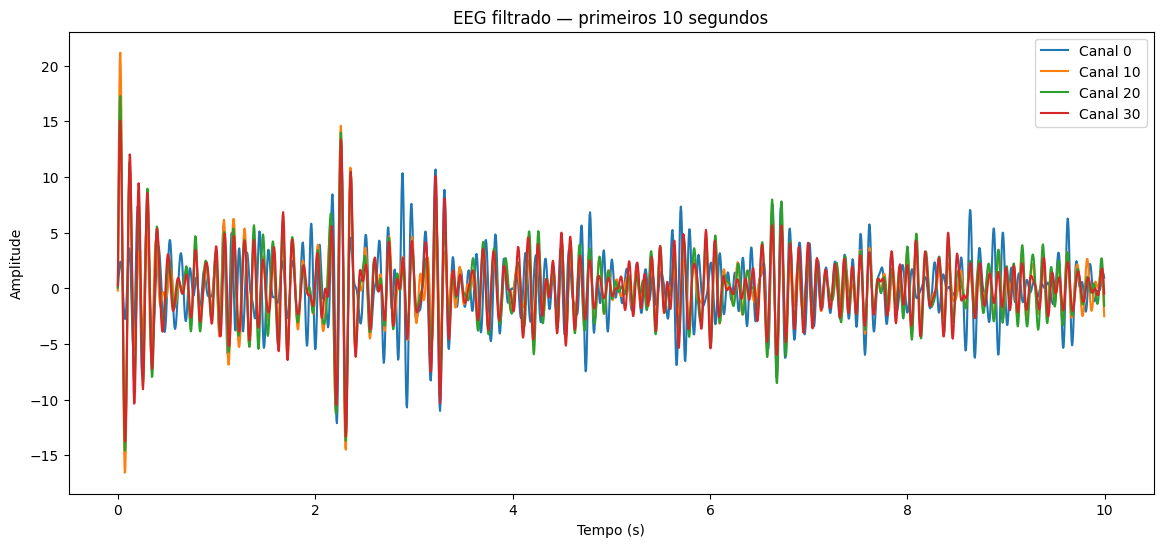

In [13]:
import matplotlib.pyplot as plt

idx_participante = 0
X = data_filtrada[idx_participante]

fs = fs_list[idx_participante]

tempo = np.arange(X.shape[0]) / fs

canais_para_plotar = [0, 10, 20, 30]

plt.figure(figsize=(14,6))

for canal in canais_para_plotar:
    plt.plot(
        tempo[:2000],
        X[:2000, canal],
        label=f"Canal {canal}"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG filtrado — primeiros 10 segundos")
plt.legend()
plt.show()

In [14]:
import gc

for var in ["data_list", "X", "X_filtrado", "X_notch", "chunk"]:
    if var in globals():
        del globals()[var]

gc.collect()

print("Memória intermediária liberada antes da criação das épocas.")

Memória intermediária liberada antes da criação das épocas.


# 4. Eventos, labels e criação das épocas

Nesta etapa são inspecionados os marcadores experimentais para construir as épocas do EEG. A lógica atual é usar o intervalo entre **cue** e **target**, pois esse intervalo representa o período em que o participante mantém a atenção encoberta antes do alvo visual.


## 4.1 Inspecionar estrutura dos trials


In [15]:
idx = 0

mat = loadmat(
    files[idx],
    squeeze_me=True,
    struct_as_record=False
)

data = mat["data"]
mrk = mat["mrk"]

trial = data.trial
labels = data.y

print("Número de trials:", len(trial))

print("\nPrimeiros trials:")
print(trial[:10])

print("\nPrimeiros labels:")
print(labels[:10])

Número de trials: 600

Primeiros trials:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros labels:
[2 1 3 1 2 4 3 6 3 3]


## 4.2 Calcular duração dos trials


In [16]:
trial_diff = np.diff(trial)

print("Primeiros tamanhos de trials:")
print(trial_diff[:10])

print("\nMédia:")
print(int(np.mean(trial_diff)))

print("\nMínimo:")
print(np.min(trial_diff))

print("\nMáximo:")
print(np.max(trial_diff))

Primeiros tamanhos de trials:
[1062  825 1063 1062  904  884 1062 1062  859 1062]

Média:
964

Mínimo:
762

Máximo:
1903


## 4.3 Inspecionar eventos cue/target


In [17]:
print("Campos dentro de mrk.target_location:")

if hasattr(mrk.target_location, "_fieldnames"):
    print(mrk.target_location._fieldnames)
else:
    print("Não é struct")

Campos dentro de mrk.target_location:
['pos', 'toe', 'fs', 'y', 'className']


## 4.4 Inspecionar campos de `target_location`


In [18]:
for campo in mrk.target_location._fieldnames:
    valor = getattr(mrk.target_location, campo)

    print("\nCampo:", campo)
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)

    if hasattr(valor, "__len__"):
        try:
            print("Primeiros valores:")
            print(valor[:20])
        except:
            pass


Campo: pos
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190 11252 12015
 13081 14127 15194 16135 17194 18256 19319 20381]

Campo: toe
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[37 30 32 30 37 39 30 41 37 32 32 34 39 37 34 37 32 41 34 41]

Campo: fs
Tipo: <class 'int'>

Campo: y
Tipo: <class 'numpy.ndarray'>
Shape: (6, 600)
Primeiros valores:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Campo: className
Tipo: <class 'numpy.ndarray'>
Shape: (6,)
Primeiros valores:
['target @1' 'target @2' 'target @3' 'target @4' 'target @5' 'target @6']


## 4.5 Calcular delay entre cue e target


In [19]:
cue_pos = data.trial
target_pos = mrk.target_location.pos

print("Primeiros cue_pos:")
print(cue_pos[:10])

print("\nPrimeiros target_pos:")
print(target_pos[:10])

delay = target_pos - cue_pos

print("\nDelay entre cue e target em amostras:")
print(delay[:20])

print("\nDelay médio em segundos:")
print(np.mean(delay) / fs)

print("\nDelay mínimo em segundos:")
print(np.min(delay) / fs)

print("\nDelay máximo em segundos:")
print(np.max(delay) / fs)

Primeiros cue_pos:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros target_pos:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190]

Delay entre cue e target em amostras:
[429 192 430 429 271 250 429 429 225 429 429 129 429 412 433 308 425 429
 430 429]

Delay médio em segundos:
1.621925

Delay mínimo em segundos:
0.645

Delay máximo em segundos:
2.17


## 4.6 Criar épocas alinhadas ao cue

**Observação técnica importante:** neste ponto, o código atual usa `idx_participante = 0`, portanto a criação de épocas está restrita ao primeiro arquivo/participante carregado. Isso deve ser mantido se o grupo decidiu analisar apenas um participante; caso contrário, a etapa precisa ser generalizada para todos os participantes.


In [20]:
idx_participante = 0
X = data_filtrada[0]

cue_pos = data.trial
target_pos = mrk.target_location.pos
target_y = mrk.target_location.y

epochs_cue_target = []
labels_cue_target = []

for i in range(len(cue_pos)):

    inicio = cue_pos[i]
    fim = target_pos[i]

    if fim > inicio and fim <= X.shape[0]:

        epoch = X[inicio:fim, :]

        classe = np.argmax(target_y[:, i])

        epochs_cue_target.append(epoch)
        labels_cue_target.append(classe)

labels_cue_target = np.array(labels_cue_target)

print("Número de epochs criadas:", len(epochs_cue_target))
print("Número de labels:", len(labels_cue_target))

print("\nPrimeiras shapes das epochs:")

for i in range(5):
    print(f"Epoch {i}:", epochs_cue_target[i].shape)

print("\nPrimeiros labels:")
print(labels_cue_target[:10])

Número de epochs criadas: 600
Número de labels: 600

Primeiras shapes das epochs:
Epoch 0: (429, 62)
Epoch 1: (192, 62)
Epoch 2: (430, 62)
Epoch 3: (429, 62)
Epoch 4: (271, 62)

Primeiros labels:
[1 0 2 0 1 3 0 5 1 2]


## 4.7 Padronizar tamanho das épocas pelo menor delay


In [21]:
delay = target_pos - cue_pos

janela_amostras = int(np.min(delay))

print("Janela escolhida (amostras):", janela_amostras)
print("Janela escolhida (segundos):", janela_amostras / fs)

epochs_padronizadas = []
labels_padronizadas = []

for epoch, label in zip(epochs_cue_target, labels_cue_target):

    epoch_fixada = epoch[:janela_amostras, :]

    epochs_padronizadas.append(epoch_fixada)
    labels_padronizadas.append(label)

epochs_padronizadas = np.array(epochs_padronizadas)
labels_padronizadas = np.array(labels_padronizadas)

print("\nShape final das epochs:")
print(epochs_padronizadas.shape)

print("\nShape final dos labels:")
print(labels_padronizadas.shape)

print("\nTotal de trials mantidos:", len(epochs_padronizadas))

Janela escolhida (amostras): 129
Janela escolhida (segundos): 0.645



Shape final das epochs:
(600, 129, 62)

Shape final dos labels:
(600,)

Total de trials mantidos: 600


In [22]:
import gc

for var in ["data_list", "data_filtrada", "X", "X_filtrado", "X_notch", "chunk"]:
    if var in globals():
        del globals()[var]

gc.collect()

print("Memória liberada antes da ICA.")

Memória liberada antes da ICA.


# 5. Limpeza por ICA

A Análise de Componentes Independentes (ICA) foi incluída como etapa de pré-processamento para investigar e, quando justificável, remover componentes associados a artefatos.

Neste notebook, a ICA é aplicada antes da extração das features por Welch e CSP. A remoção de componentes, entretanto, não deve ser feita de forma automática apenas pela numeração do componente, pois a ordem dos componentes ICA não garante que artefatos oculares estejam sempre nos componentes 0, 1 ou 2.

A seleção dos componentes removidos deve ser baseada na inspeção dos mapas topográficos e das séries temporais dos componentes.

## 5.1 Ajustar ICA e visualizar componentes

Not setting metadata
600 matching events found


No baseline correction applied
0 projection items activated
Fitting ICA to data using 62 channels (please be patient, this may take a while)


/tmp/ipykernel_62444/1707430402.py:15: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_mne)


Selecting by number: 20 components
Fitting ICA took 3.2s.
Mapas topográficos dos componentes ICA:


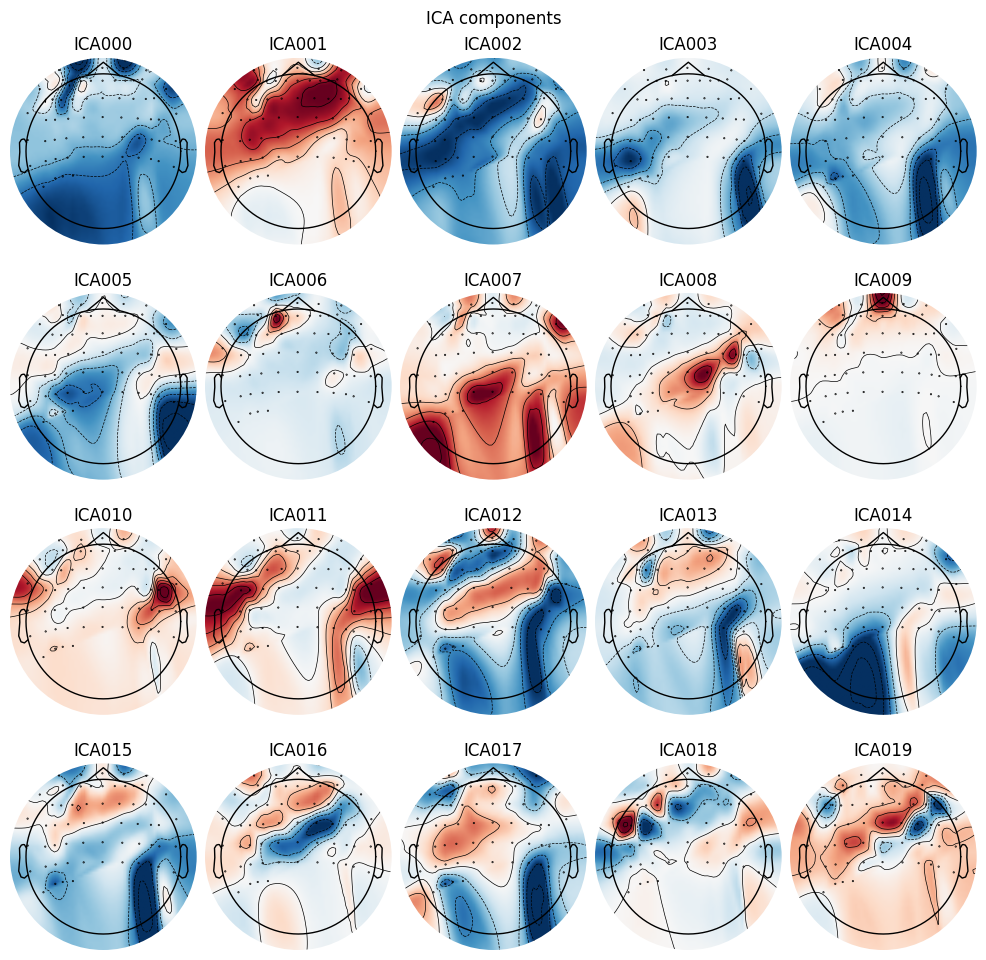

Séries temporais dos componentes ICA:
Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


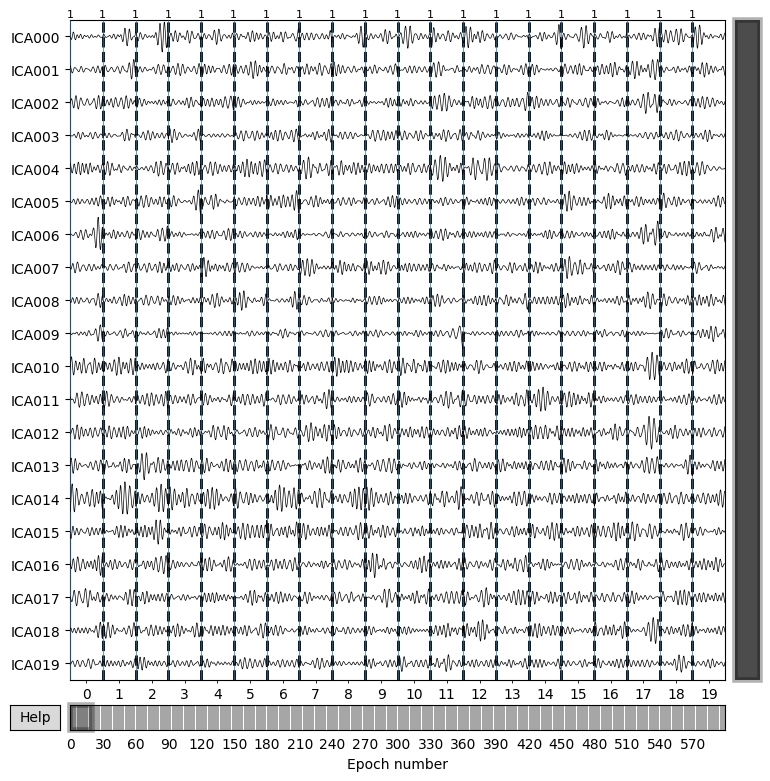

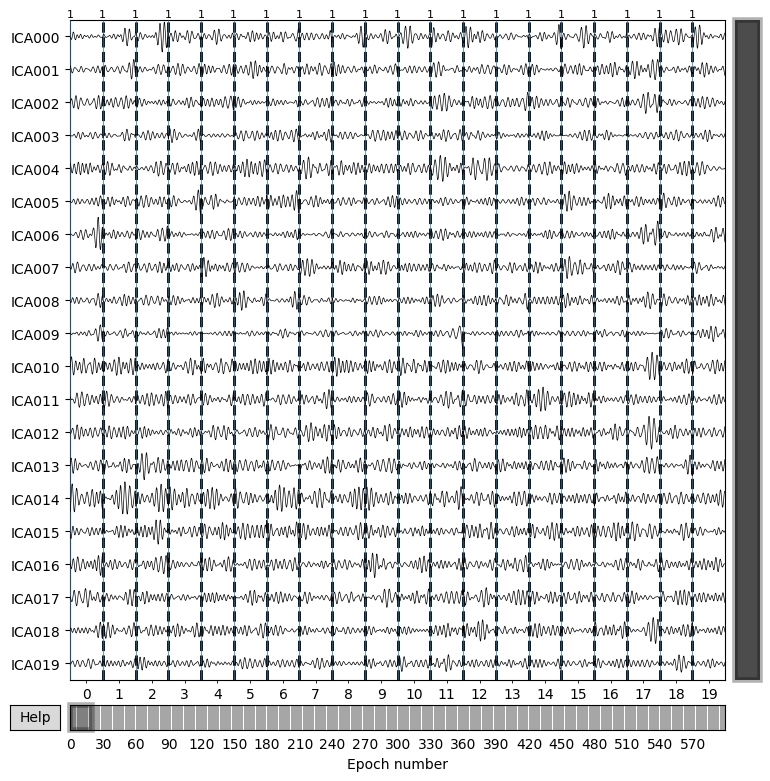

In [23]:
import mne
import numpy as np
from mne.preprocessing import ICA

montage_std = mne.channels.make_standard_montage('standard_1020')
std_ch_names = montage_std.ch_names[:62]

info = mne.create_info(ch_names=std_ch_names, sfreq=200, ch_types='eeg')
info.set_montage(montage_std)

data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

ica = ICA(n_components=20, random_state=42, method='fastica')
ica.fit(epochs_mne)

print("Mapas topográficos dos componentes ICA:")
ica.plot_components()

print("Séries temporais dos componentes ICA:")
ica.plot_sources(epochs_mne)

## 5.2 Definir componentes artefatuais

Após a inspeção visual, os componentes considerados artefatuais devem ser inseridos manualmente na lista `componentes_artefato`.

Critérios usados para marcação:

- topografia compatível com artefato ocular ou muscular;
- comportamento temporal com picos abruptos ou padrão não fisiológico;
- componente sem padrão compatível com atividade neural relevante para a tarefa.

No momento, a lista deve permanecer vazia até que os componentes sejam inspecionados e justificados.

In [24]:
componentes_artefato = []

ica.exclude = componentes_artefato

print(f"Componentes marcados para remoção: {ica.exclude}")

epochs_limpas = ica.apply(epochs_mne.copy())

epochs_padronizadas_clean = epochs_limpas.get_data().transpose(0, 2, 1)

print("\n" + "="*30)
print("PROCESSO ICA CONCLUÍDO")
print(f"Shape original: {epochs_padronizadas.shape}")
print(f"Shape após ICA: {epochs_padronizadas_clean.shape}")
print("="*30)

Componentes marcados para remoção: []
Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 0 ICA components
    Projecting back using 62 PCA components

PROCESSO ICA CONCLUÍDO
Shape original: (600, 129, 62)
Shape após ICA: (600, 129, 62)


# 6. Modelo baseline: Welch + SVM

Esta abordagem estabelece o baseline espectral do projeto. A hipótese central é que a direção da atenção visual encoberta modula o ritmo Alfa nas regiões posteriores do cérebro. Portanto, a extração da densidade espectral de potência (PSD) dessa banda deve fornecer características discriminativas suficientes para que o classificador (SVM) separe as seis direções experimentais.


## 6.1 Extrair potência alfa via Welch

Nesta etapa, utilizamos o Método de Welch para focar no domínio da frequência e calcular a Densidade Espectral de Potência (PSD) em cada um dos 32 canais de forma independente.

A extração é intencionalmente restrita a 32 canais, focando nas áreas de interesse relacionadas ao ritmo Alfa (córtex parietal e occipital). Essa redução de dimensionalidade espacial é fundamental para mitigar o ruído de regiões menos relevantes (como as frontais) e prevenir o overfitting do modelo.


In [25]:
import numpy as np
from scipy.signal import welch

fs = 200

indices_canais = list(range(30, 62))
n_canais_selecionados = len(indices_canais)

X_welch_raw = []

print(f"Calculando PSD via Welch para {len(epochs_padronizadas_clean)} trials...")
print(f"Foco: {n_canais_selecionados} canais posteriores selecionados.")

for trial in epochs_padronizadas_clean:
    trial_psds = []

    for ch_idx in indices_canais:

        freqs, psd = welch(trial[:, ch_idx],
                           fs=fs,
                           nperseg=256,
                           noverlap=128)
        trial_psds.append(psd)

    X_welch_raw.append(trial_psds)

X_welch_raw = np.array(X_welch_raw)

idx_alfa = np.where((freqs >= 8) & (freqs <= 14))[0]

X_features_welch = np.mean(X_welch_raw[:, :, idx_alfa], axis=-1)

X_features_welch = np.log10(X_features_welch + 1e-10)

print("\n" + "="*40)
print("PSD CALCULADO (WELCH SUAVIZADO)")
print(f"Shape bruto: {X_welch_raw.shape}")
print(f"Shape final para o SVM: {X_features_welch.shape}")
print(f"Canais processados: {n_canais_selecionados} (Posteriores)")
print("="*40)

Calculando PSD via Welch para 600 trials...
Foco: 32 canais posteriores selecionados.


/tmp/ipykernel_62444/1002263790.py:19: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 129, using nperseg = 129
  freqs, psd = welch(trial[:, ch_idx],



PSD CALCULADO (WELCH SUAVIZADO)
Shape bruto: (600, 32, 65)
Shape final para o SVM: (600, 32)
Canais processados: 32 (Posteriores)


## 6.2 Padronizar features por z-score
Esta transformação é necessária antes da aplicação do classificador, pois padroniza os valores de potência da banda Alfa extraídos via Método de Welch. Isso garante que a potência de todos os eletrodos contribua de forma equilibrada para o aprendizado do modelo, evitando que canais com amplitudes naturalmente maiores se sobreponham em relação a outros.


In [26]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_padronizado = scaler.fit_transform(X_features_welch)

print("="*40)
print("VERIFICAÇÃO DA PADRONIZAÇÃO")
print(f"Shape final: {X_padronizado.shape}")

print("\nMédia das primeiras 5 features (Alvo ~ 0):")
print(np.mean(X_padronizado[:, :5], axis=0))

print("\nDesvio padrão das primeiras 5 features (Alvo = 1):")
print(np.std(X_padronizado[:, :5], axis=0))
print("="*40)

VERIFICAÇÃO DA PADRONIZAÇÃO
Shape final: (600, 32)

Média das primeiras 5 features (Alvo ~ 0):
[-2.04928667e-17  2.13162821e-16 -3.30430128e-16 -2.93341740e-16
 -1.52840703e-16]

Desvio padrão das primeiras 5 features (Alvo = 1):
[1. 1. 1. 1. 1.]


## 6.3 Classificar com SVM e avaliar baseline:
Nesta fase do pipeline, implementamos o algoritmo de classificação Support Vector Machine (SVM) para categorizar os sinais de EEG em uma das 6 direções de atenção visual possíveis. O classificador utiliza como entrada a matriz de características já escalonada via Z-score, contendo a potência da banda Alfa de 32 canais posteriores.

A escolha do SVM fundamenta-se na sua robustez ao mapear os dados em um espaço de 32 dimensões (correspondentes aos eletrodos selecionados), buscando os hiperplanos que maximizam a margem de separação entre as classes. Para o multiclasse (6 direções), o modelo adota a estratégia One-Vs-One (OvO),criando fronteiras de decisão específicas para cada par de direções.

Devido ao número restrito de épocas (trials), o SVM é eficaz na prevenção do sobreajuste (overfitting), baseando sua fronteira de decisão apenas nas amostras mais importantes para definir os limites entre as classes (os vetores de suporte). O desempenho é validado via Validação Cruzada, garantindo que as acurácias obtidas de 20.50% (multiclasse) e de 62.77% (binária) demonstrem a capacidade do modelo de conseguir identificar os padrões de atenção no EEG.



Treinando modelo Binário...


Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...

RESUMO DE PERFORMANCE (BASELINE)
Dados de Entrada: Welch + Log10 (Banda Alfa | 32 Canais)
Melhores parâmetros Multiclasse: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Acurácia Binária (Direção 0 vs 1): 62.77%
Acurácia Multiclasse (Todas as 6): 20.50%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


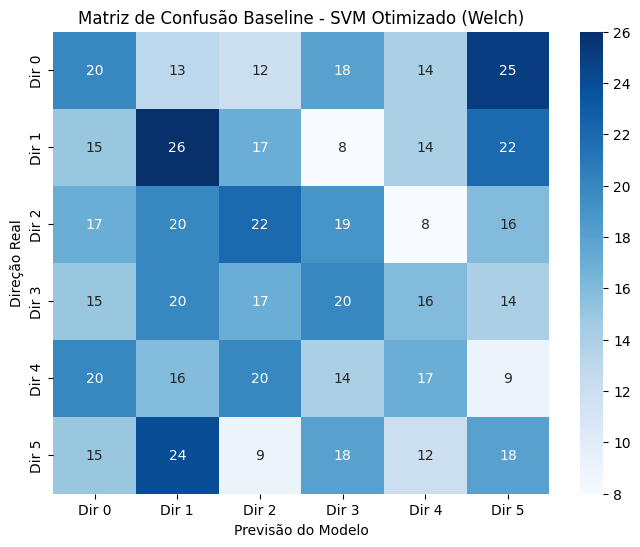

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_final = X_features_welch
y_final = labels_padronizadas

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', random_state=42))
])

param_grid_bin = {
    'svm__C': [0.1, 1, 10, 50, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear']
}

print("Treinando modelo Binário...")

p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_bin = GridSearchCV(
    pipe_svm,
    param_grid_bin,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_bin.fit(X_bin, y_bin)
melhor_modelo_bin = grid_bin.best_estimator_

acc_binaria = cross_val_score(
    melhor_modelo_bin,
    X_bin,
    y_bin,
    cv=cv,
    scoring='accuracy'
).mean()


# --- 3. OTIMIZAÇÃO MULTICLASSE  ---
# usamos 'f1_macro' para PROIBIR o SVM de ignorar classes.
# Também forçamos o formato 'ovo' (One-Vs-One) para que ele crie duelos diretos entre todas as classes.
param_grid_multi = {
    'svm__C': [0.1, 1, 10, 50, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf']
}

print("Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...")
grid_multi = GridSearchCV(
    pipe_svm,
    param_grid_multi,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid_multi.fit(X_final, y_final)
melhor_modelo_multi = grid_multi.best_estimator_

acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv, scoring='accuracy').mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)

print("\n" + "="*50)
print(f"RESUMO DE PERFORMANCE (BASELINE)")
print("="*50)
print(f"Dados de Entrada: Welch + Log10 (Banda Alfa | {X_final.shape[1]} Canais)")
print(f"Melhores parâmetros Multiclasse: {grid_multi.best_params_}")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)


# --- 5. PLOT DA MATRIZ AZUL ---
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Baseline - SVM Otimizado (Welch)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

## 6.4 Radar de desempenho por direção — Welch + SVM
Para melhorar a visualização dos resultados obtidos na matriz de confusão, implementamos o gráfico de um Radar de desempenho por direção, no qual os seis vértices do hexágono representam as diferentes direções de atenção visual do dataset (0 a 5). 
 
O objetivo é evidenciar a acurácia individual do sistema em cada uma das direções. Enquanto a linha pontilhada vermelha indica o nível de chance ao acaso (16,67%), a linha azul destaca a performance real do modelo, revelando uma sensibilidade maior nas direções 0 e 2. A linha verde tracejada representa a média global de 20,17%, permitindo observar que, embora o desempenho seja quase igual ao limiar de aleatoriedade em diversas classes, o modelo ainda consegue prever minimamente algumas direções.




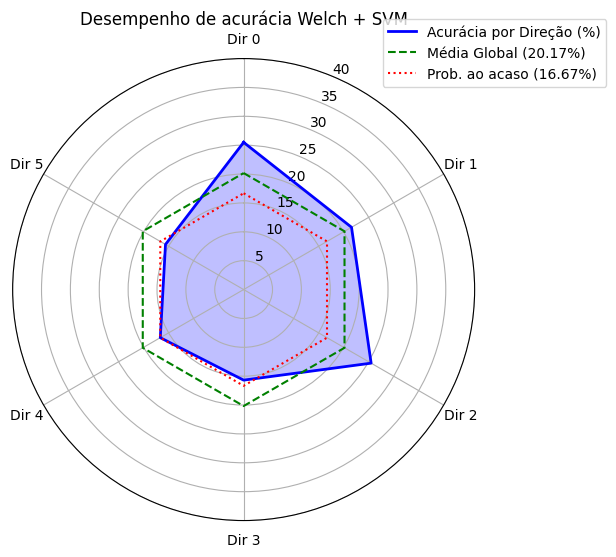

In [29]:
import numpy as np
import matplotlib.pyplot as plt

acertos = np.array([26, 22, 26, 16, 16, 15])

totais = np.array([102, 102, 102, 102, 96, 96])

accuracy_per_dir = (acertos / totais) * 100
labels = ['Dir 0', 'Dir 1', 'Dir 2', 'Dir 3', 'Dir 4', 'Dir 5']
num_vars = len(labels)

stats = np.concatenate((accuracy_per_dir, [accuracy_per_dir[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2, label='Acurácia por Direção (%)')

media_global_val = 20.17
media_global = [media_global_val] * (num_vars + 1)
ax.plot(angles, media_global, color='green', linestyle='--', label=f'Média Global ({media_global_val}%)')

chance_val = 16.67
chance = [chance_val] * (num_vars + 1)
ax.plot(angles, chance, color='red', linestyle=':', label=f'Prob. ao acaso ({chance_val}%)')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 40)

plt.title('Desempenho de acurácia Welch + SVM')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# 7. Modelo espacial: CSP + SVM

O CSP é usado para extrair componentes espaciais que maximizam diferenças entre classes. Diferentemente do Welch, que calcula potência por canal de forma independente, o CSP explora combinações espaciais entre canais.

Essa é a principal comparação metodológica do notebook:

- **Welch + SVM:** baseline espectral, sem filtro espacial supervisionado.
- **CSP + SVM:** abordagem espacial supervisionada, mais adequada para padrões distribuídos no EEG.


## 7.1 Extrair features espaciais com CSP


In [30]:
import numpy as np
from mne.decoding import CSP
# 1. PREPARAÇÃO DOS DADOS
X_time = np.transpose(epochs_padronizadas_clean, (0, 2, 1))
y = labels_padronizadas

# 2. 
# Adicionamos 'rank' para garantir que canais redundantes não sujem a matriz
# O parâmetro 'cov_estimator' garante a maior robustez estatística possível
csp = CSP(n_components=10,
          reg='ledoit_wolf',
          rank='full',
          log=True,
          norm_trace=False)

print("Extraindo componentes espaciais otimizados...")
X_csp = csp.fit_transform(X_time, y)

# 3. CONEXÃO COM O SVM

X_features = X_csp

print("\n" + "="*40)
print("EXTRAÇÃO CSP FINALIZADA")
print(f"Shape para o SVM: {X_features.shape}")
print("Pode rodar o classificador.")
print("="*40)

Extraindo componentes espaciais otimizados...
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF


Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.

EXTRAÇÃO CSP FINALIZADA
Shape para o SVM: (600, 10)
Pode rodar o classificador.


# 7.2 Classificar features CSP com SVM: 
Nesta fase do pipeline, implementamos o algoritmo de classificação Support Vector Machine (SVM) para categorizar os sinais de EEG a partir dos componentes espaciais extraídos pelo CSP. O classificador recebe como entrada as características (features) que já foram matematicamente otimizadas para maximizar a separação entre as seis direções de atenção visual possíveis.

A escolha do SVM justifica-se por sua robustez ao lidar com vetores de características em espaços de alta dimensionalidade. Para o problema multiclasse, o modelo utiliza a estratégia One-Vs-One (OvO), permitindo definir a fronteira de decisão mais estável para os padrões de variância projetados pelos filtros espaciais.

O desempenho é validado via Validação Cruzada Estratificada, mitigando o risco de sobreajuste (overfitting) e garantindo a generalização dos resultados. A acurácia obtida de 41.33% (multiclasse) e 75.01% (binária) demonstra a superioridade desta abordagem, evidenciando que a inclusão de informação espacial supervisionada permite uma identificação muito mais precisa dos padrões de atenção no EEG em comparação ao baseline espectral.



Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...
Melhores parâmetros binários: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Melhores parâmetros multiclasse: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Dados de Entrada: CSP + SVM | 10 componentes CSP
Acurácia Binária (Direção 0 vs 1): 75.01%
Acurácia Multiclasse (Todas as 6): 41.33%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


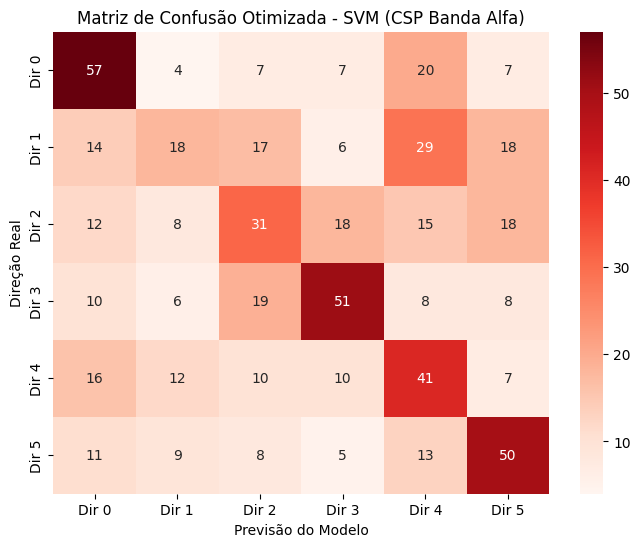

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

# Usando as features espaciais extraídas pelo CSP
X_final = X_features
y_final = labels_padronizadas

# Configuração da Validação Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- OTIMIZAÇÃO (Grid Search) ---
# Vamos testar diferentes configurações do SVM
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear'] # Adicionando o linear, que às vezes é melhor para BCI multiclasse
}

print("Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...")
grid_search = GridSearchCV(SVC(class_weight='balanced', random_state=42), param_grid, cv=cv, scoring='accuracy')

# --- PARTE A: AVALIAÇÃO BINÁRIA (Melhor Par: 0 vs 1) ---
p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_search.fit(X_bin, y_bin)
melhor_modelo_bin = grid_search.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()
print(f"Melhores parâmetros binários: {grid_search.best_params_}")


# --- PARTE B: AVALIAÇÃO MULTICLASSE (1 em 6) ---
grid_search.fit(X_final, y_final)
melhor_modelo_multi = grid_search.best_estimator_
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv).mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)
print(f"Melhores parâmetros multiclasse: {grid_search.best_params_}")


# --- RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print("="*50)
print(f"Dados de Entrada: CSP + SVM | {X_final.shape[1]} componentes CSP")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)

# Plot da Matriz Multiclasse
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Otimizada - SVM (CSP Banda Alfa)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

## 7.3 Radar de desempenho por direção — CSP + SVM:

 Seguindo o mesmo raciocínio da matriz de confusão do Welch + SVM, vamos melhorar a visualização dos resultados obtidos na matriz de confusão do CSP + SVM implementando o gráfico de um Radar de desempenho por direção, no qual os seis vértices do hexágono representam as diferentes direções de atenção visual do dataset (0 a 5). 
 
O objetivo é verificar se a inclusão de informações espaciais, intrínseca ao algoritmo CSP, resulta em uma distribuição de acertos mais equilibrada ou se acentua a dominância de classes específicas. A linha pontilhada vermelha ainda representa a probabilidade do acaso (16,6%), a linha azul representa a performance real do modelo, revelando uma sensibilidade maior nos eixos verticais (Direções 0 e 3), já a linha verde tracejada destaca a média global de 34,33%, permitindo observar que, embora o desempenho varie entre as direções com as diagonais apresentando maior desafio de classificação, todas as classes operam de forma consistente e de forma superior ao limite de "chute" do modelo caso ele estivesse apenas chutando a direção onde o participante olhou em vez de tentar aprender com os dados.

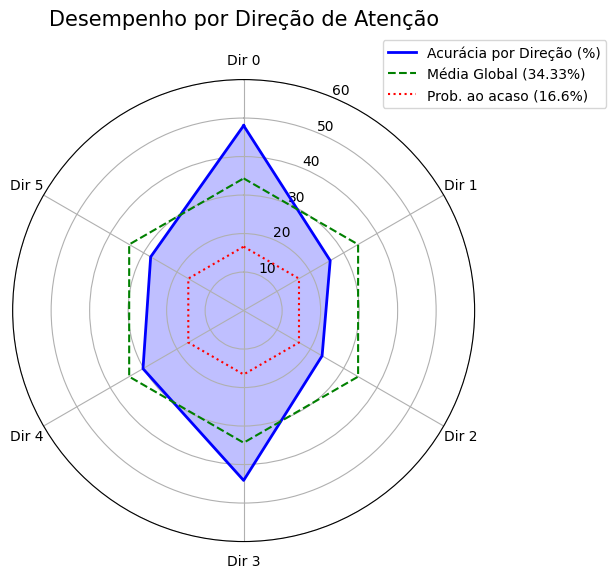

In [32]:
import numpy as np
import matplotlib.pyplot as plt

acertos = np.array([49, 27, 24, 45, 32, 29])
totais = np.array([102, 104, 102, 102, 106, 104])

accuracy_per_dir = (acertos / totais) * 100
labels = ['Dir 0', 'Dir 1', 'Dir 2', 'Dir 3', 'Dir 4', 'Dir 5']
num_vars = len(labels)

stats = np.concatenate((accuracy_per_dir, [accuracy_per_dir[0]]))
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2, label='Acurácia por Direção (%)')

media_global = [34.33] * (num_vars + 1)
ax.plot(angles, media_global, color='green', linestyle='--', label='Média Global (34.33%)')

chance = [16.6] * (num_vars + 1)
ax.plot(angles, chance, color='red', linestyle=':', label='Prob. ao acaso (16.6%)')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 60)

plt.title('Desempenho por Direção de Atenção', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# 8. Interpretação técnica dos resultados

## 8.1 Resultado principal

O baseline **Welch + SVM** apresentou desempenho próximo ao nível de chance multiclasse, indicando que a potência alfa média por canal não foi suficiente para separar bem as seis direções de atenção.

O pipeline **CSP + SVM** apresentou melhora substancial, sugerindo que a informação discriminativa não está apenas na potência alfa isolada de cada canal, mas também na distribuição espacial do sinal entre os eletrodos posteriores.

## 8.2 Interpretação para o relatório

A diferença entre Welch e CSP sustenta a ideia de que a atenção visual encoberta produz padrões espaciais sutis no EEG. O Welch funciona como um baseline simples de potência espectral; o CSP atua como um filtro espacial supervisionado, tornando mais evidentes as diferenças entre classes.

## 8.3 Ponto metodológico importante

Este dataset não representa um SSVEP clássico com estímulos piscando em frequências fixas. Portanto, o trabalho deve evitar afirmar que foi implementado um SSVEP tradicional. A formulação mais segura é dizer que o projeto analisa **modulações oscilatórias em banda alfa associadas à atenção visual encoberta**, usando uma lógica de processamento inspirada em BCIs visuais baseadas em frequência.
